In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df['Outcome_labels'] = np.where(df['Outcome'] == 1, 'Diabetic','No Diabetic')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Outcome_labels
0,6,148,72,35,0,33.6,0.627,50,1,Diabetic
1,1,85,66,29,0,26.6,0.351,31,0,No Diabetic
2,8,183,64,0,0,23.3,0.672,32,1,Diabetic
3,1,89,66,23,94,28.1,0.167,21,0,No Diabetic
4,0,137,40,35,168,43.1,2.288,33,1,Diabetic


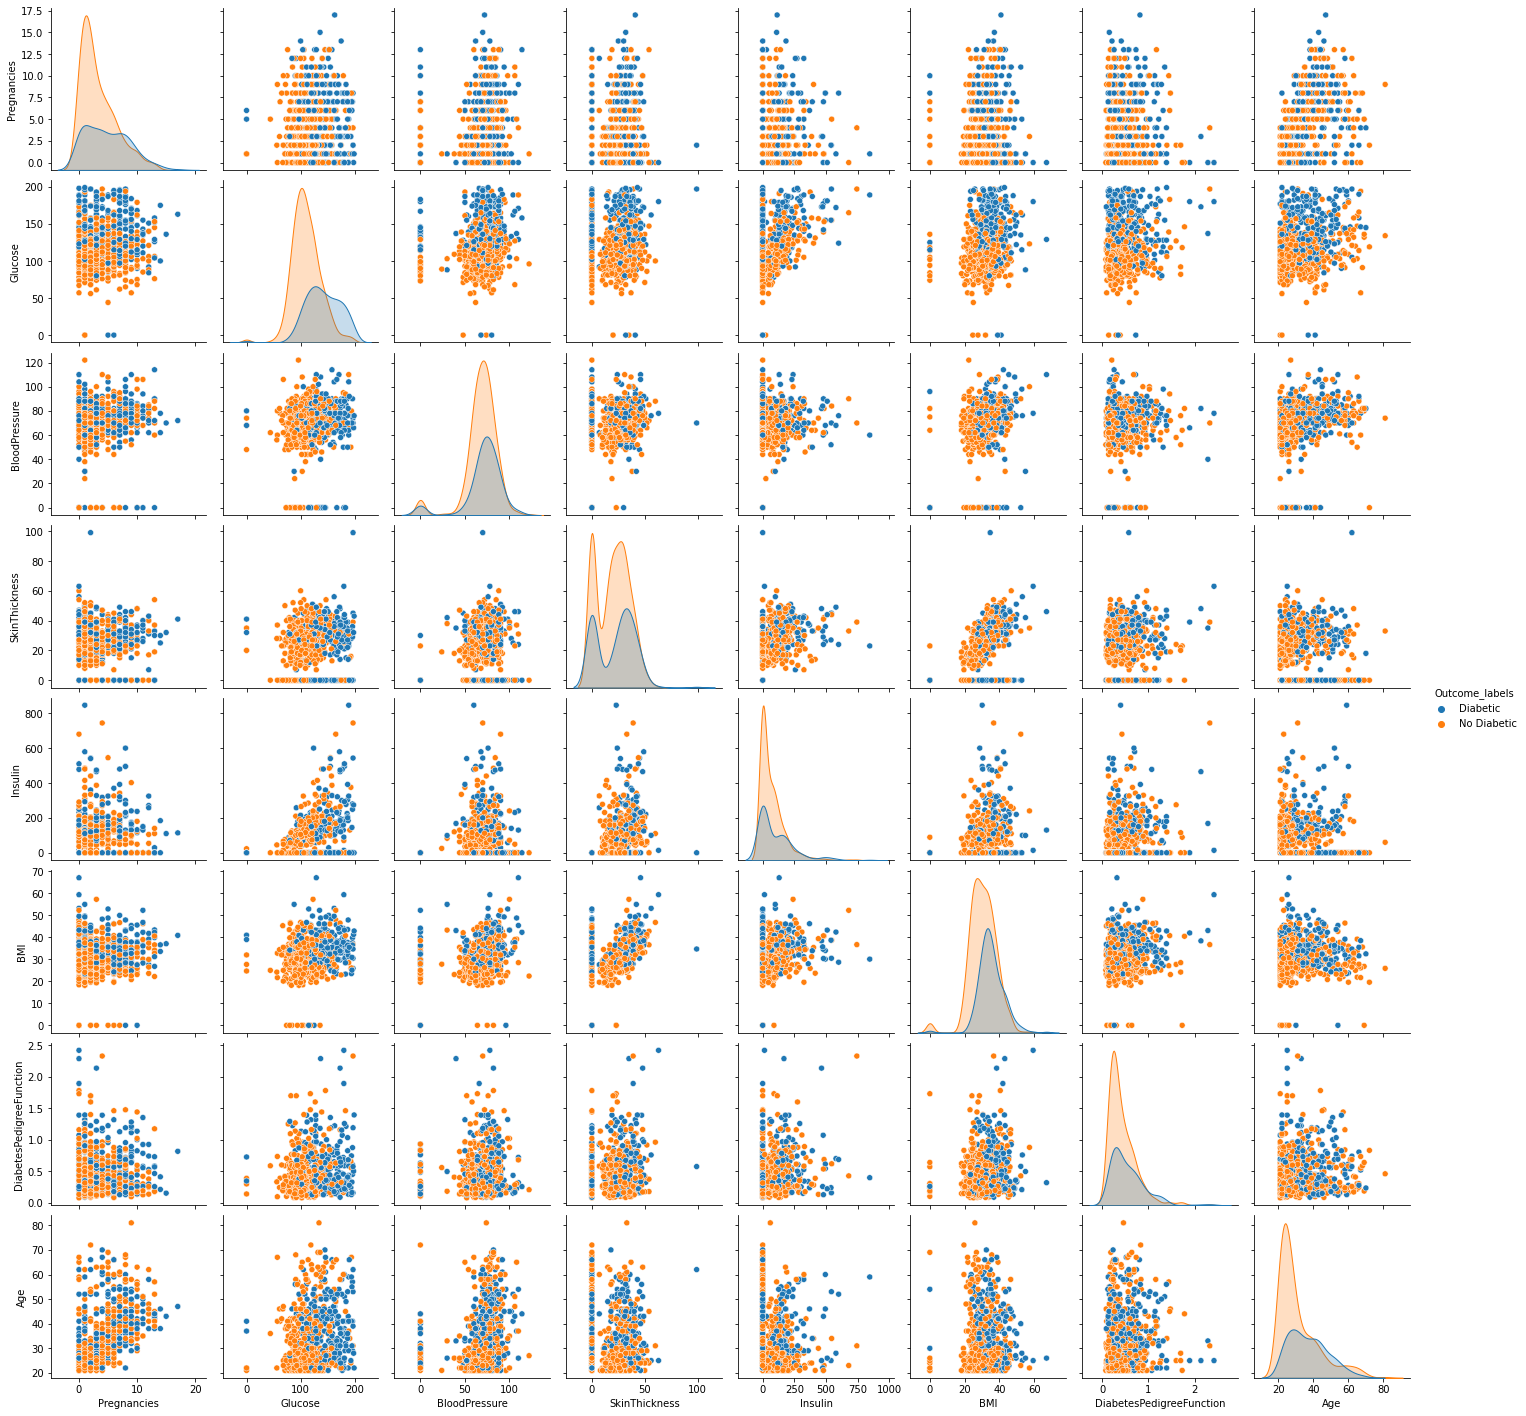

In [6]:
sns.pairplot(df.drop('Outcome',axis=1),hue='Outcome_labels')

In [7]:
# Dependent and Independent Features
X = df.drop(['Outcome','Outcome_labels'],axis=1).values
y = df['Outcome'].values

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=2022)

In [9]:
# Torch Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

In [10]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [11]:
# Model Building

class Model(nn.Module):
    def __init__(self, input_features=8, hidden1=20, hidden2=20, out_features=2):
        super().__init__()
        self.f_connected1 = nn.Linear(input_features, hidden1)
        self.f_connected2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, out_features)
        
    def forward(self, x):
        x = F.relu(self.f_connected1(x))
        x = F.relu(self.f_connected2(x))
        x = self.out(x)
        return x

In [12]:
torch.manual_seed(2022)
model = Model()

In [13]:
model.parameters

<bound method Module.parameters of Model(
  (f_connected1): Linear(in_features=8, out_features=20, bias=True)
  (f_connected2): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=2, bias=True)
)>

In [14]:
# Backward Propagation - Define loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [15]:
epochs = 500
final_loss = []

for i in range(epochs):
    i += 1
    y_pred = model.forward(X_train)
    
    loss = loss_function(y_pred, y_train)
    final_loss.append(loss)
    if i%10==1:
        print("Epoch number: {} and the loss : {}".format(i,loss.item()))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch number: 1 and the loss : 4.267565727233887
Epoch number: 11 and the loss : 0.8218510150909424
Epoch number: 21 and the loss : 0.6796354651451111
Epoch number: 31 and the loss : 0.6508417129516602
Epoch number: 41 and the loss : 0.6281273365020752
Epoch number: 51 and the loss : 0.6176064610481262
Epoch number: 61 and the loss : 0.6077420115470886
Epoch number: 71 and the loss : 0.6001495718955994
Epoch number: 81 and the loss : 0.594032883644104
Epoch number: 91 and the loss : 0.5891515612602234
Epoch number: 101 and the loss : 0.585430920124054
Epoch number: 111 and the loss : 0.5821298360824585
Epoch number: 121 and the loss : 0.5793050527572632
Epoch number: 131 and the loss : 0.5767686367034912
Epoch number: 141 and the loss : 0.5741915702819824
Epoch number: 151 and the loss : 0.5716289281845093
Epoch number: 161 and the loss : 0.5691893100738525
Epoch number: 171 and the loss : 0.5667106509208679
Epoch number: 181 and the loss : 0.5643507838249207
Epoch number: 191 and the 

In [16]:
final_losses = [i.detach().numpy() for i in final_loss]

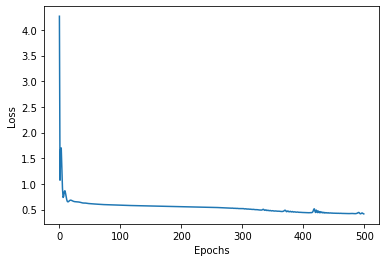

In [17]:
plt.plot(range(epochs),final_losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [18]:
# Making Prediction
predictions = []
with torch.no_grad():
    for idx, data in enumerate(X_test):
        y_pred = model(data)
        predictions.append(y_pred.argmax().item())

In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
cm

array([[100,   8],
       [ 27,  19]])

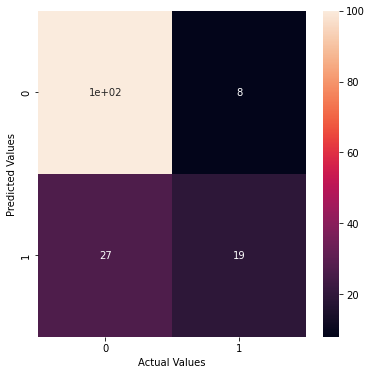

In [20]:
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [21]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, predictions)
acc

0.7727272727272727

In [22]:
list(df.iloc[5,:-2])

[5, 116, 74, 0, 0, 25.6, 0.201, 30]

In [23]:
# change the data 
new_data_list = [5.0, 116.0, 74.0, 40.0, 0.0, 25.6, 0.601, 45.0]

In [24]:
new_data = torch.tensor(new_data_list)

In [25]:
# predict new data

with torch.no_grad():
    new_pred = model(new_data)
    print(new_pred)
    print(new_pred.argmax().item())

tensor([1.5995, 0.7914])
0
